Introduction - refer to OneDrive document for instructions on how to use this script. Any questions or problems please email daniel.coen@universityofgalway.ie

Link to OneDrive - https://unioulu-my.sharepoint.com/:f:/r/personal/ffedorik_univ_yo_oulu_fi/Documents/RIAQ%20-%20Interreg%20NPA/WP2/ISES%20Conference%202026?csf=1&web=1&e=HkiMix

Please upload your CO2 data CSV file:


Saving RIAQ_FIN_002-0133_pythonAER.csv to RIAQ_FIN_002-0133_pythonAER.csv

Loaded file: RIAQ_FIN_002-0133_pythonAER.csv

Dataset loaded successfully!
Total records: 99057
Houses: 2
Date range: 2025-12-14 to 2026-04-14

VENTILATION RATE ANALYSIS WITH QUALITY CONTROL

Processing RIAQ_FIN_002...
  2025-12-21 (Decay 2): REJECTED - Insufficient decay
  2025-12-21 (Decay 3): REJECTED - Insufficient decay
  2025-12-21 (Decay 4): REJECTED - Insufficient decay
  2025-12-21 (Decay 6): ✓ ACH = 0.280 h⁻¹ (R² = 0.971)
  2025-12-23 (Decay 1): ✓ ACH = 0.395 h⁻¹ (R² = 0.863)
  2025-12-23 (Decay 2): REJECTED - Insufficient decay
  2025-12-24 (Decay 3): REJECTED - Insufficient decay
  2025-12-24 (Decay 4): REJECTED - Insufficient decay
  2025-12-24 (Decay 7): ✓ ACH = 0.413 h⁻¹ (R² = 0.984)
  2025-12-24 (Decay 8): REJECTED - Insufficient decay
  2025-12-24 (Decay 9): REJECTED - Insufficient decay
  2025-12-25 (Decay 2): REJECTED - Insufficient decay
  2025-12-25 (Decay 3): REJECTED - Insufficient decay
 

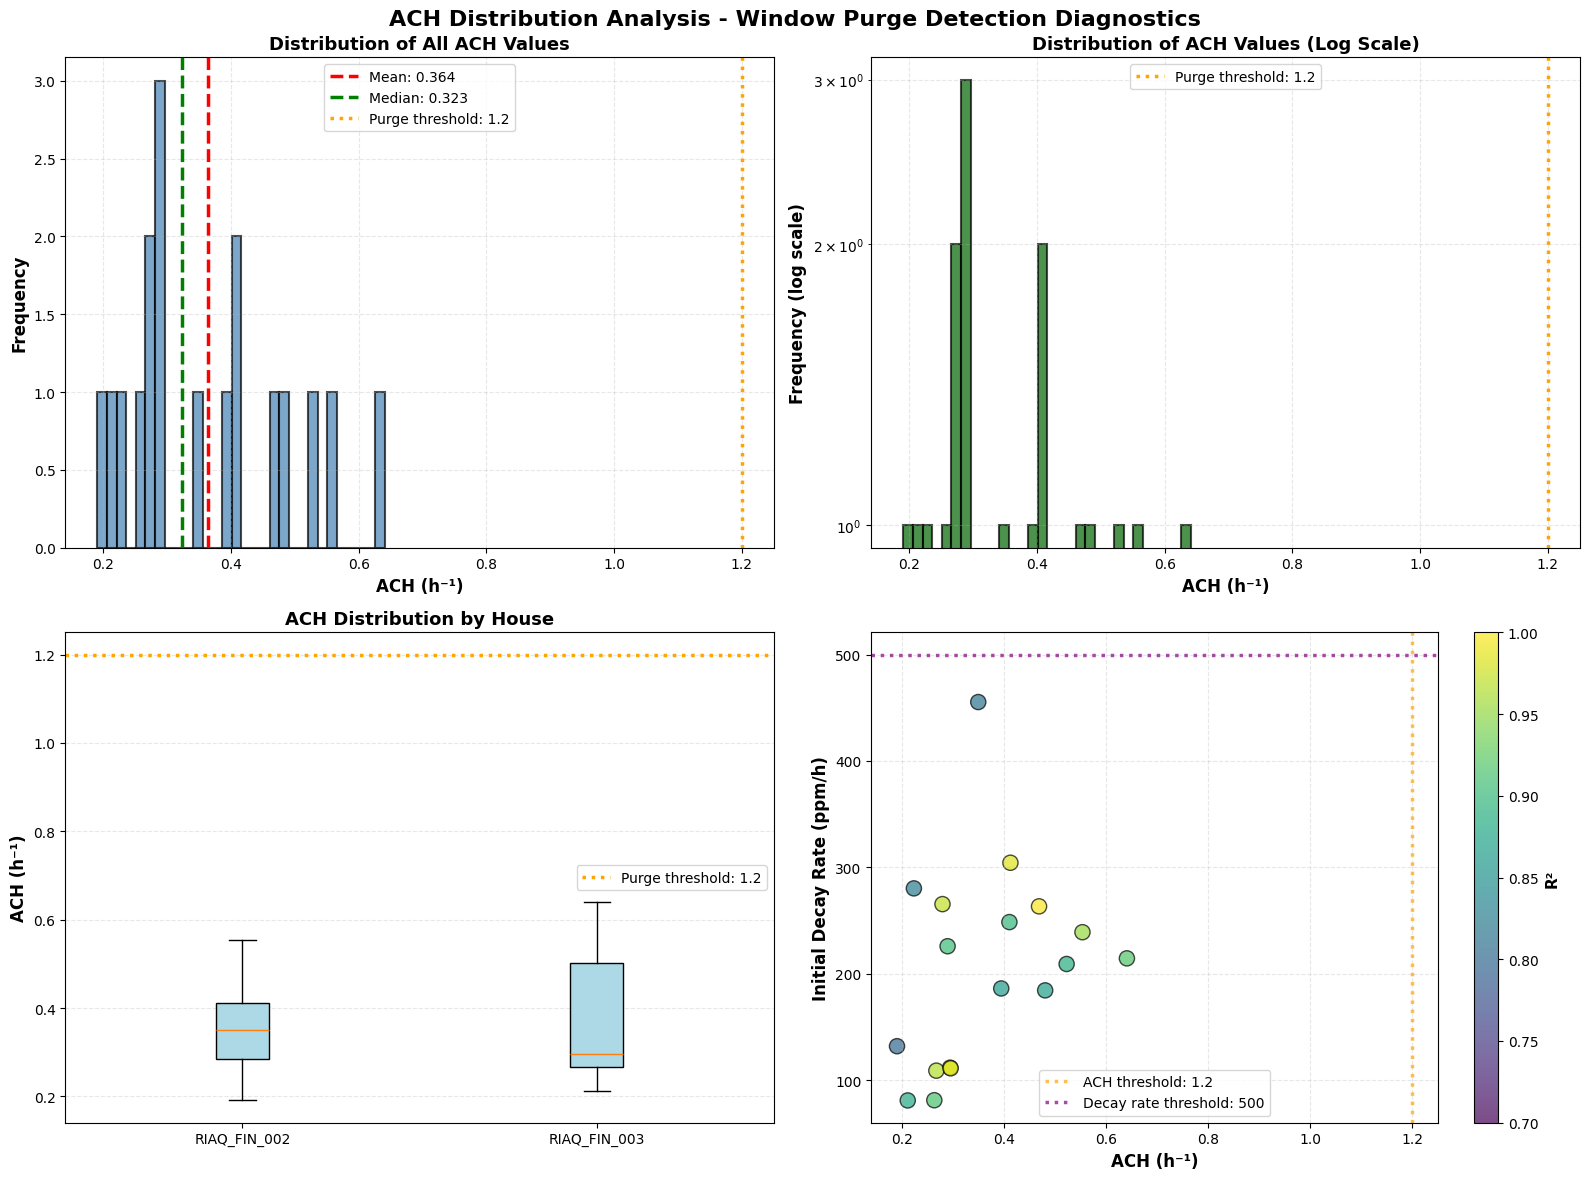


✓ Results saved to: ventilation_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


REJECTED CASES (449 total)
     HouseNo       Date  Decay_event                           Reason
RIAQ_FIN_002 2025-12-21            2 Insufficient decay (30.6% < 63%)
RIAQ_FIN_002 2025-12-21            3 Insufficient decay (30.3% < 63%)
RIAQ_FIN_002 2025-12-21            4 Insufficient decay (30.9% < 63%)
RIAQ_FIN_002 2025-12-23            2 Insufficient decay (21.1% < 63%)
RIAQ_FIN_002 2025-12-24            3 Insufficient decay (36.9% < 63%)
RIAQ_FIN_002 2025-12-24            4 Insufficient decay (25.8% < 63%)
RIAQ_FIN_002 2025-12-24            8 Insufficient decay (34.2% < 63%)
RIAQ_FIN_002 2025-12-24            9 Insufficient decay (38.5% < 63%)
RIAQ_FIN_002 2025-12-25            2 Insufficient decay (19.7% < 63%)
RIAQ_FIN_002 2025-12-25            3 Insufficient decay (34.7% < 63%)
RIAQ_FIN_002 2025-12-25            4 Insufficient decay (58.7% < 63%)
RIAQ_FIN_002 2025-12-25            5 Insufficient decay (20.0% < 63%)
RIAQ_FIN_002 2025-12-25            6 Insufficient decay (32.4%

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


QUALITY CONTROL SUMMARY
  - Baseline ambient CO2 value: 420 ppm (fixed)
  - Minimum final CO2: 500 ppm
  - Minimum decay fraction: 63.0%
  - Minimum R²: 0.7
  - Normal infiltration ACH range: 0.05 - 1.2 h⁻¹
  - Maximum initial decay rate: 500 ppm/h
  - Maximum consecutive increases: 3
  ⚠️  WINDOW PURGE DETECTION ACTIVE
     → Filters ACH > 1.2 h⁻¹ or decay rate > 500 ppm/h

Results: 18 accepted (3.9%), 449 rejected (96.1%)

ANALYSIS COMPLETE


In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# ========== QUALITY CONTROL PARAMETERS ==========

# Fixed baseline
AMBIENT_CO2 = 420

# Decay completeness thresholds
MIN_FINAL_CO2 = 500              # ppm - reject if end of decay too close to baseline
MIN_DECAY_FRACTION = 0.63        # Require decay to at least 63% of starting value

# Model fit quality
MIN_R_SQUARED = 0.70             # Coefficient of determination threshold

# Ventilation rate ranges (normal infiltration only)
MIN_ACH = 0.05                   # h⁻¹ - minimum reasonable ventilation
MAX_ACH_NORMAL = 1.2             # h⁻¹ - PURGE DETECTION THRESHOLD

# Alternative purge detection (optional secondary check)
MAX_DECAY_RATE = 500             # ppm/h - initial decay rate threshold

# Decay monotonicity
MAX_INCREASES = 3                # Allow up to 3 small increases during decay window

# ============ END PARAMETERS ============


def exp_decay_fixed_base(t, C0, ACH):
    """
    Exponential decay model for CO2 concentration with fixed baseline.

    Parameters:
    - t: time in hours since start of decay
    - C0: initial CO2 concentration (ppm, start of decay period)
    - ACH: air changes per hour (1/h)

    Returns:
    - CO2 concentration at time t (baseline set to 420 ppm)
    """
    return (C0 - AMBIENT_CO2) * np.exp(-ACH * t) + AMBIENT_CO2


def find_all_decay_periods(house_data,
                           min_peak_above=250,       # peak must be ≥ 250 ppm above baseline
                           target_end_ppm=500,       # stop decay when CO2 <= this
                           max_hours=4):             # or after this many hours
    """
    Identify CO2 decay periods for a given house-day.

    For each detected peak:
      - Start at the peak time
      - Extend forward in time until CO2 reaches 'target_end_ppm'
        or 'max_hours' have passed (whichever comes first)
      - Require at least 10 data points
    """
    day_data = house_data.sort_values('DateTime')
    co2_vals = day_data['CO2.ppm'].values
    times_hours = (day_data['DateTime'] - day_data['DateTime'].iloc[0]).dt.total_seconds() / 3600

    # Smooth to find robust peaks
    co2_smooth = gaussian_filter1d(co2_vals, sigma=1.5)

    # Find peaks that are sufficiently above baseline
    peaks, properties = find_peaks(
        co2_smooth,
        height=AMBIENT_CO2 + min_peak_above,
        distance=15  # at least ~75 minutes between peaks at 5‑min intervals
    )

    decay_periods = []

    for peak_idx in peaks:
        peak_time = day_data.iloc[peak_idx]['DateTime']
        peak_co2  = day_data.iloc[peak_idx]['CO2.ppm']

        # Consider data up to max_hours after the peak
        window_mask = (day_data['DateTime'] >= peak_time) & \
                      (day_data['DateTime'] <= peak_time + pd.Timedelta(hours=max_hours))
        window_df = day_data[window_mask].copy()

        if window_df.empty:
            continue

        # Find first time CO2 drops below target_end_ppm within this window
        below = window_df[window_df['CO2.ppm'] <= target_end_ppm]
        if not below.empty:
            # Cut window at that first point
            end_time = below.iloc[0]['DateTime']
            decay_df = window_df[window_df['DateTime'] <= end_time].copy()
        else:
            # Otherwise use full window up to max_hours
            decay_df = window_df.copy()

        if len(decay_df) < 10:
            continue

        decay_periods.append({
            'peak_idx': peak_idx,
            'peak_time': peak_time,
            'decay_data': decay_df
        })

    return decay_periods


def calculate_r_squared(observed, predicted):
    """Calculate coefficient of determination R^2."""
    ss_res = np.sum((observed - predicted) ** 2)
    ss_tot = np.sum((observed - np.mean(observed)) ** 2)
    if ss_tot == 0:
        return 0
    return 1 - (ss_res / ss_tot)


def check_monotonic_decay(co2_vals, max_increases=3):
    """Check if decay is generally monotonic (allowing small fluctuations)."""
    increases = 0
    for i in range(1, len(co2_vals)):
        if co2_vals[i] > co2_vals[i-1]:
            increases += 1
    return increases <= max_increases


def check_purge_ventilation(ACH_fit, C0_fit, initial_decay_rate,
                           MAX_ACH_NORMAL=1.2, MAX_DECAY_RATE=500):
    """
    Detect window purge ventilation events.

    Parameters:
    -----------
    ACH_fit : float
        Fitted air changes per hour (h⁻¹)
    C0_fit : float
        Initial CO2 concentration (ppm)
    initial_decay_rate : float
        Initial decay rate (ppm/h)
    MAX_ACH_NORMAL : float
        Maximum ACH for normal infiltration (default 1.2 h⁻¹)
    MAX_DECAY_RATE : float
        Maximum initial decay rate for normal infiltration (default 500 ppm/h)

    Returns:
    --------
    is_purge : bool
        True if window purge detected, False if normal infiltration
    reason : str
        Description of detection method if purge found
    """

    # Check 1: ACH threshold
    if ACH_fit > MAX_ACH_NORMAL:
        return True, f"ACH {ACH_fit:.3f} h⁻¹ > {MAX_ACH_NORMAL} h⁻¹"

    # Check 2: Initial decay rate
    if initial_decay_rate > MAX_DECAY_RATE:
        return True, f"Decay rate {initial_decay_rate:.0f} ppm/h > {MAX_DECAY_RATE} ppm/h"

    # Not a purge event
    return False, None


# --- COLAB UPLOAD ---
print("Please upload your CO2 data CSV file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"\nLoaded file: {filename}")

df = pd.read_csv(filename)

# Drop any unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Handle both timestamp formats
try:
    df['DateTime'] = pd.to_datetime(df['TimeStamp'], format='%m/%d/%Y %H:%M:%S')
except ValueError:
    try:
        df['DateTime'] = pd.to_datetime(df['TimeStamp'], format='%m/%d/%Y %H:%M')
    except ValueError:
        df['DateTime'] = pd.to_datetime(df['TimeStamp'])

df = df.sort_values(['HouseNo.', 'DateTime']).reset_index(drop=True)
df['Date'] = df['DateTime'].dt.date
df['Hour'] = df['DateTime'].dt.hour

print(f"\nDataset loaded successfully!")
print(f"Total records: {len(df)}")
print(f"Houses: {df['HouseNo.'].nunique()}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

# --- ANALYSIS WITH QUALITY CONTROL ---
print("\n" + "="*80)
print("VENTILATION RATE ANALYSIS WITH QUALITY CONTROL")
print("="*80)

results = []
rejected_cases = []

for house in df['HouseNo.'].unique():
    house_data = df[df['HouseNo.'] == house]
    dates = house_data['Date'].unique()
    print(f"\nProcessing {house}...")

    for date in dates:
        day_data = house_data[house_data['Date'] == date]
        decay_periods = find_all_decay_periods(day_data)

        for decay_num, decay_info in enumerate(decay_periods, 1):
            decay_df = decay_info['decay_data'].copy()
            decay_df['t_hours'] = (decay_df['DateTime'] - decay_df['DateTime'].iloc[0]).dt.total_seconds() / 3600

            co2_vals = decay_df['CO2.ppm'].values
            times = decay_df['t_hours'].values

            # Skip if no real decay
            if len(times) < 10 or (co2_vals[0] - co2_vals[-1]) < 50:
                continue

            C0_guess = co2_vals[0]
            ACH_guess = 0.5

            try:
                lb = [min(co2_vals) - 50, MIN_ACH]
                ub = [max(co2_vals) + 50, 10]
                popt, pcov = curve_fit(
                    exp_decay_fixed_base,
                    times,
                    co2_vals,
                    p0=[C0_guess, ACH_guess],
                    bounds=(lb, ub),
                    maxfev=10000
                )

                # ========== QUALITY CONTROL FILTERS ==========

                # Extract fitted parameters
                C0_fit, ACH_fit = popt

                # Calculate additional metrics
                predicted = exp_decay_fixed_base(times, C0_fit, ACH_fit)
                r_squared = calculate_r_squared(co2_vals, predicted)
                initial_decay_rate = ACH_fit * (C0_fit - AMBIENT_CO2)  # ppm per hour

                # Textbook-style decay fraction: start vs end of decay window, relative to ambient
                C_start = co2_vals[0]      # measured start of decay
                C_end   = co2_vals[-1]     # measured end of decay

                if C_start > AMBIENT_CO2:
                    decay_fraction = (C_start - C_end) / (C_start - AMBIENT_CO2)
                else:
                    decay_fraction = 0

                # FILTER 2: Final CO2 threshold
                if C_end < MIN_FINAL_CO2:
                    rejected_cases.append({
                        'HouseNo': house,
                        'Date': date,
                        'Decay_event': decay_num,
                        'Reason': f'Final CO2 ({C_end:.0f} ppm) < {MIN_FINAL_CO2} ppm'
                    })
                    print(f"  {date} (Decay {decay_num}): REJECTED - Final CO2 too low")
                    continue

                # FILTER 3: Decay fraction
                if decay_fraction < MIN_DECAY_FRACTION:
                    rejected_cases.append({
                        'HouseNo': house,
                        'Date': date,
                        'Decay_event': decay_num,
                        'Reason': f'Insufficient decay ({decay_fraction*100:.1f}% < {MIN_DECAY_FRACTION*100:.0f}%)'
                    })
                    print(f"  {date} (Decay {decay_num}): REJECTED - Insufficient decay")
                    continue

                # FILTER 4: Model fit quality
                if r_squared < MIN_R_SQUARED:
                    rejected_cases.append({
                        'HouseNo': house,
                        'Date': date,
                        'Decay_event': decay_num,
                        'Reason': f'Poor fit (R² = {r_squared:.3f} < {MIN_R_SQUARED})'
                    })
                    print(f"  {date} (Decay {decay_num}): REJECTED - Poor model fit")
                    continue



                # ========== ALL QUALITY CHECKS PASSED ==========

                # Accept this measurement
                results.append({
                    'HouseNo': house,
                    'Date': date,
                    'Decay_event': decay_num,
                    'C0_ppm': round(C0_fit, 1),
                    'C0_timestamp': decay_df.iloc[0]['DateTime'].strftime('%Y-%m-%d %H:%M'),
                    'ACH_per_hour': round(ACH_fit, 3),
                    'Initial_decay_rate_ppm_h': round(initial_decay_rate, 1),
                    'R_squared': round(r_squared, 3),
                    'Decay_fraction': round(decay_fraction, 2),
                    'NumDataPoints': len(decay_df)
                })

                print(f"  {date} (Decay {decay_num}): ✓ ACH = {ACH_fit:.3f} h⁻¹ (R² = {r_squared:.3f})")

            except RuntimeError:
                rejected_cases.append({
                    'HouseNo': house,
                    'Date': date,
                    'Decay_event': decay_num,
                    'Reason': 'Curve fit failed'
                })
                print(f"  {date} (Decay {decay_num}): REJECTED - Curve fit failed")
                continue

vent_df = pd.DataFrame(results)
rejected_df = pd.DataFrame(rejected_cases)

print("\n" + "="*80)
print("VENTILATION RATE ANALYSIS RESULTS")
print("="*80)

if len(vent_df) > 0:
    print(vent_df.to_string(index=False))

    print("\n" + "="*80)
    print("SUMMARY STATISTICS BY HOUSE")
    print("="*80)

    summary = vent_df.groupby('HouseNo')['ACH_per_hour'].agg(['mean', 'std', 'min', 'max', 'count'])
    summary.columns = ['Mean_ACH', 'Std_ACH', 'Min_ACH', 'Max_ACH', 'N_decays']
    summary = summary.round(3)
    print(summary)

    # --- VISUALIZATION SECTION ---
    print("\n" + "="*80)
    print("GENERATING DIAGNOSTIC VISUALIZATIONS")
    print("="*80)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('ACH Distribution Analysis - Window Purge Detection Diagnostics',
                 fontsize=16, fontweight='bold')

    # Plot 1: Histogram with bimodal distribution
    ax1 = axes[0, 0]
    ax1.hist(vent_df['ACH_per_hour'], bins=30, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5)
    ax1.axvline(vent_df['ACH_per_hour'].mean(), color='red', linestyle='--', linewidth=2.5,
                label=f'Mean: {vent_df["ACH_per_hour"].mean():.3f}')
    ax1.axvline(vent_df['ACH_per_hour'].median(), color='green', linestyle='--', linewidth=2.5,
                label=f'Median: {vent_df["ACH_per_hour"].median():.3f}')
    ax1.axvline(MAX_ACH_NORMAL, color='orange', linestyle=':', linewidth=2.5,
                label=f'Purge threshold: {MAX_ACH_NORMAL}')
    ax1.set_xlabel('ACH (h⁻¹)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution of All ACH Values', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3, linestyle='--')

    # Plot 2: Log scale histogram (better for bimodal)
    ax2 = axes[0, 1]
    ax2.hist(vent_df['ACH_per_hour'], bins=30, alpha=0.7, color='darkgreen', edgecolor='black', linewidth=1.5)
    ax2.set_yscale('log')
    ax2.axvline(MAX_ACH_NORMAL, color='orange', linestyle=':', linewidth=2.5,
                label=f'Purge threshold: {MAX_ACH_NORMAL}')
    ax2.set_xlabel('ACH (h⁻¹)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency (log scale)', fontsize=12, fontweight='bold')
    ax2.set_title('Distribution of ACH Values (Log Scale)', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3, which='both', linestyle='--')

    # Plot 3: Box plot by house
    ax3 = axes[1, 0]
    houses = vent_df['HouseNo'].unique()
    box_data = [vent_df[vent_df['HouseNo'] == h]['ACH_per_hour'].values for h in houses]
    bp = ax3.boxplot(box_data, labels=houses, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax3.axhline(MAX_ACH_NORMAL, color='orange', linestyle=':', linewidth=2.5,
                label=f'Purge threshold: {MAX_ACH_NORMAL}')
    ax3.set_ylabel('ACH (h⁻¹)', fontsize=12, fontweight='bold')
    ax3.set_title('ACH Distribution by House', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3, axis='y', linestyle='--')

    # Plot 4: Scatter - ACH vs Initial Decay Rate
    ax4 = axes[1, 1]
    scatter = ax4.scatter(vent_df['ACH_per_hour'],
                         vent_df['Initial_decay_rate_ppm_h'],
                         c=vent_df['R_squared'],
                         s=120,
                         alpha=0.7,
                         cmap='viridis',
                         edgecolor='black',
                         linewidth=1,
                         vmin=MIN_R_SQUARED,
                         vmax=1.0)
    ax4.axvline(MAX_ACH_NORMAL, color='orange', linestyle=':', linewidth=2.5, alpha=0.7,
                label=f'ACH threshold: {MAX_ACH_NORMAL}')
    ax4.axhline(MAX_DECAY_RATE, color='purple', linestyle=':', linewidth=2.5, alpha=0.7,
                label=f'Decay rate threshold: {MAX_DECAY_RATE}')
    ax4.set_xlabel('ACH (h⁻¹)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Initial Decay Rate (ppm/h)', fontsize=12, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('R²', fontsize=11, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig('ach_diagnostic_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Diagnostic plot saved as 'ach_diagnostic_analysis.png'")
    plt.show()

    # Save results
    output_filename = 'ventilation_results.csv'
    vent_df.to_csv(output_filename, index=False)
    print(f"\n✓ Results saved to: {output_filename}")
    files.download(output_filename)
    files.download('ach_diagnostic_analysis.png')
else:
    print("No valid decay periods found that passed quality control filters.")

if len(rejected_df) > 0:
    print("\n" + "="*80)
    print(f"REJECTED CASES ({len(rejected_df)} total)")
    print("="*80)
    print(rejected_df.to_string(index=False))

    rejected_filename = 'rejected_cases.csv'
    rejected_df.to_csv(rejected_filename, index=False)
    print(f"\n✓ Rejected cases saved to: {rejected_filename}")
    files.download(rejected_filename)

print("\n" + "="*80)
print("QUALITY CONTROL SUMMARY")
print("="*80)
print(f"  - Baseline ambient CO2 value: {AMBIENT_CO2} ppm (fixed)")
print(f"  - Minimum final CO2: {MIN_FINAL_CO2} ppm")
print(f"  - Minimum decay fraction: {MIN_DECAY_FRACTION*100}%")
print(f"  - Minimum R²: {MIN_R_SQUARED}")
print(f"  - Normal infiltration ACH range: {MIN_ACH} - {MAX_ACH_NORMAL} h⁻¹")
print(f"  - Maximum initial decay rate: {MAX_DECAY_RATE} ppm/h")
print(f"  - Maximum consecutive increases: {MAX_INCREASES}")
print(f"  ⚠️  WINDOW PURGE DETECTION ACTIVE")
print(f"     → Filters ACH > {MAX_ACH_NORMAL} h⁻¹ or decay rate > {MAX_DECAY_RATE} ppm/h")

if len(results) + len(rejected_cases) > 0:
    total = len(results) + len(rejected_cases)
    pct_accepted = len(results) / total * 100
    pct_rejected = len(rejected_cases) / total * 100
    print(f"\nResults: {len(results)} accepted ({pct_accepted:.1f}%), "
          f"{len(rejected_cases)} rejected ({pct_rejected:.1f}%)")
else:
    print("\nNo decay periods found for analysis")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
